<a href="https://colab.research.google.com/github/fboldt/aulas-am-bsi/blob/main/aula09a%20-%20Valida%C3%A7%C3%A3o%20Cruzada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)

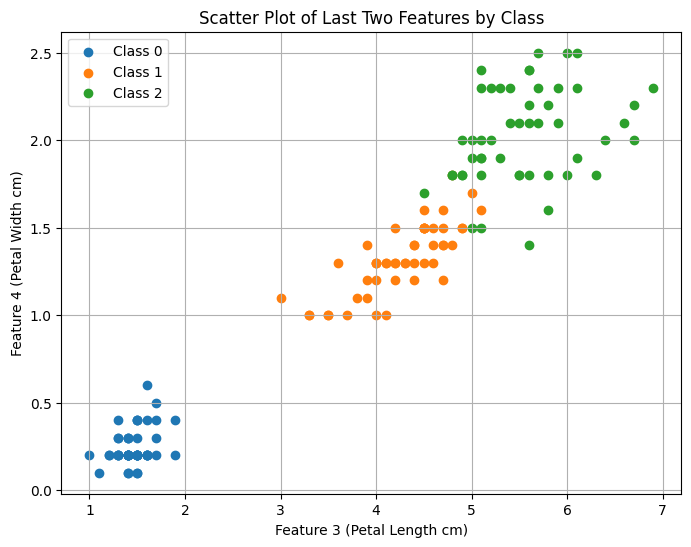

In [65]:
import matplotlib.pyplot as plt
import numpy as np

# Extract the last two features (columns 2 and 3 for 0-indexed array)
X_features = X[:, -2:]

# Get unique classes
unique_classes = np.unique(y)

plt.figure(figsize=(8, 6))
for i, class_label in enumerate(unique_classes):
    # Select data points for the current class
    class_data = X_features[y == class_label]
    plt.scatter(class_data[:, 0], class_data[:, 1], label=f'Class {class_label}')

plt.xlabel('Feature 3 (Petal Length cm)')
plt.ylabel('Feature 4 (Petal Width cm)')
plt.title('Scatter Plot of Last Two Features by Class')
plt.legend()
plt.grid(True)
plt.show()

# Seleção de modelos


## Resubstituição
Não avalia a generalização de modelos de aprendizado de máquina. Deve ser usado raramente apenas como "Debug".

In [7]:
from sklearn.metrics._plot.confusion_matrix import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

model = KNeighborsClassifier(n_neighbors=1)

def resubstituicao(model, X, y):
  model.fit(X, y)
  y_pred = model.predict(X)
  print(confusion_matrix(y, y_pred))
  return accuracy_score(y, y_pred)

print(f"resubstuição: Acc = {resubstituicao(model, X, y)}")

[[50  0  0]
 [ 0 50  0]
 [ 0  0 50]]
resubstuição: Acc = 1.0


## Holdout
Avalia a generalização de forma muito limitada. Mas é necessário para datasets muito grandes.

In [64]:
import numpy as np

def train_test_split(X, y, test_size, random_state):
  n = len(X)
  idxs = np.arange(n)
  np.random.seed(random_state)
  np.random.shuffle(idxs)
  n_test = int(n * test_size)
  n_train = n - n_test
  X_train = X[idxs[:n_train]]
  X_test = X[idxs[n_train:]]
  y_train = y[idxs[:n_train]]
  y_test = y[idxs[n_train:]]
  return X_train, X_test, y_train, y_test

def holdout(model, X, y, test_size=0.2, random_state=None):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  print(confusion_matrix(y_test, y_pred))
  return accuracy_score(y_test, y_pred)

print(f"holdout: Acc = {holdout(model, X, y, random_state=None)}")

[[11  0  0]
 [ 0  6  0]
 [ 0  1 12]]
holdout: Acc = 0.9666666666666667


In [84]:
def stratified_train_test_split(X, y, test_size=0.2, random_state=None):
  n = len(X)
  np.random.seed(random_state)
  classes = np.unique(y)
  idxs_by_class = {cls: np.where(y == cls)[0] for cls in classes}
  X_train = []
  X_test = []
  y_train = []
  y_test = []
  for cls in classes:
    np.random.shuffle(idxs_by_class[cls])
    n_test = int(len(idxs_by_class[cls]) * test_size)
    n_train = len(idxs_by_class[cls]) - n_test
    X_train.extend(X[idxs_by_class[cls][:n_train]])
    X_test.extend(X[idxs_by_class[cls][n_train:]])
    y_train.extend([cls] * n_train)
    y_test.extend([cls] * n_test)
  return np.array(X_train), np.array(X_test), np.array(y_train), np.array(y_test)

def stratified_holdout(model, X, y, test_size=0.2, random_state=None):
  X_train, X_test, y_train, y_test = stratified_train_test_split(X, y,
                                                      test_size=test_size,
                                                      random_state=random_state)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  print(confusion_matrix(y_test, y_pred))
  return accuracy_score(y_test, y_pred)

print(f"stratified_holdout: Acc = {stratified_holdout(model, X, y, random_state=None)}")

[[10  0  0]
 [ 0  8  2]
 [ 0  1  9]]
stratified_holdout: Acc = 0.9


In [139]:
def repeated_holdout(model, X, y, test_size=0.2, random_state=None, n_repeats=5):
  scores = []
  np.random.seed(random_state)
  for _ in range(n_repeats):
    seed = np.random.randint(1e6)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size,
                                                        random_state=seed)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores.append(accuracy_score(y_test, y_pred))
  return scores

scores = repeated_holdout(model, X, y, random_state=None)
print(f"repeated_holdout: Acc = {np.mean(scores)}, {np.std(scores)}")

repeated_holdout: Acc = 0.9466666666666667, 0.03399346342395189


In [141]:
def KFold_cross_validation(model, X, y, n_folds=5, random_state=None):
  scores = []
  n = len(X)
  idxs = np.arange(n)
  np.random.seed(random_state)
  np.random.shuffle(idxs)
  fold_size = n // n_folds
  for fold in range(n_folds):
    X_train = X[np.concatenate((idxs[:fold*fold_size], idxs[(fold+1)*fold_size:]))]
    X_test = X[idxs[fold*fold_size:(fold+1)*fold_size]]
    y_train = y[np.concatenate((idxs[:fold*fold_size], idxs[(fold+1)*fold_size:]))]
    y_test = y[idxs[fold*fold_size:(fold+1)*fold_size]]
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores.append(accuracy_score(y_test, y_pred))
  return scores

scores = KFold_cross_validation(model, X, y, random_state=None)
print(f"KFold_cross_validation: Acc = {np.mean(scores)}, {np.std(scores)}")

KFold_cross_validation: Acc = 0.96, 0.02494438257849294


In [157]:
def reapeated_KFold_cross_validation(model, X, y, n_folds=5, n_repeats=5, random_state=None):
  scores = []
  np.random.seed(random_state)
  for _ in range(n_repeats):
    seed = np.random.randint(1e6)
    score = KFold_cross_validation(model, X, y, n_folds=n_folds, random_state=seed)
    scores.append(score)
  return scores

scores = reapeated_KFold_cross_validation(model, X, y, random_state=None)
print(f"reapeated_KFold_cross_validation: Acc = {np.mean(scores)}, {np.std(scores)}")

reapeated_KFold_cross_validation: Acc = 0.9573333333333334, 0.02407396011369038
